# 회귀 실습 — Diamonds 가격 예측

이번엔 앞서 연습한 EDA를 바탕으로 실제 **회귀 문제**를 하나 풀어보겠습니다.

사용할 데이터는 다이아몬드의 특성과 가격이 담긴 **Diamonds** 데이터셋입니다. seaborn에 내장되어 있어 별도 다운로드 없이 바로 불러올 수 있습니다.

목표는 캐럿, 컷, 색상, 투명도 등 다이아몬드의 특성으로 **가격(`price`)을 예측**하는 것입니다.

### 데이터 기본 정보

| 컬럼 | 뜻 |
|---|---|
| `carat` | 캐럿 (무게) |
| `cut` | 컷 등급 (Fair < Good < Very Good < Premium < Ideal) |
| `color` | 색상 등급 (J가 가장 낮고 D가 가장 높음) |
| `clarity` | 투명도 등급 (I1이 가장 낮고 IF가 가장 높음) |
| `depth` | 깊이 비율 (%) |
| `table` | 테이블 비율 (%) |
| `price` | **가격 (정답, 단위: 달러)** |
| `x`, `y`, `z` | 가로/세로/깊이 길이 (mm) |

`cut`, `color`, `clarity`는 순서가 있는 범주형(순서형) 변수라는 점이 특징입니다. 하나씩 살펴보겠습니다.

## 1. 데이터 불러오기 & 기본 정보

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("diamonds")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [2]:
print(df.shape)
df.info()

(53940, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


약 5만 4천 개의 관측치가 있고, `cut`/`color`/`clarity`가 문자열(object, 정확히는 category)입니다.

결측치도 확인해보겠습니다.

In [3]:
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

price와 가장 연관성이 깊을 것 같은 컬럼은 어느 컬럼인가요?

결측치는 없네요. 이번엔 예측 대상인 `price`의 분포부터 확인해보겠습니다.

## 2. 타겟(price) 분포 확인

In [4]:
df['price'].describe()

count    53940.000000
mean      3932.799722
std       3989.439738
min        326.000000
25%        950.000000
50%       2401.000000
75%       5324.250000
max      18823.000000
Name: price, dtype: float64

Text(0.5, 1.0, 'price')

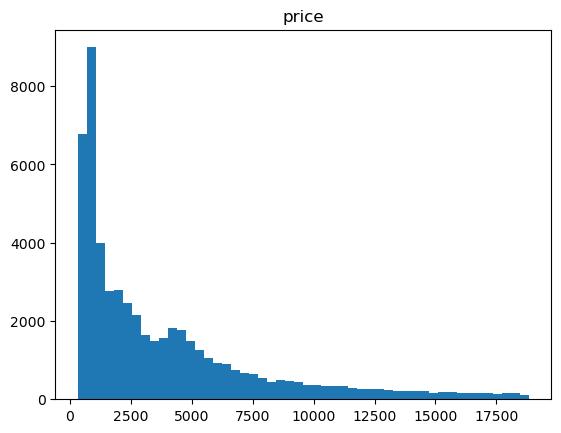

In [8]:
plt.hist(df['price'], bins=50)
plt.title("price")

`price`는 저가 다이아몬드 쪽에 크게 몰려있고 고가로 갈수록 꼬리가 길게 늘어지는 분포입니다.

이 점은 나중에 모델을 학습할 때 다시 활용해보겠습니다. 일단은 원래 `price`로 진행합니다.

## 3. 특성 살펴보기

먼저 수치형 변수들이 `price`와 어떤 관계가 있는지 산점도로 확인해보겠습니다.

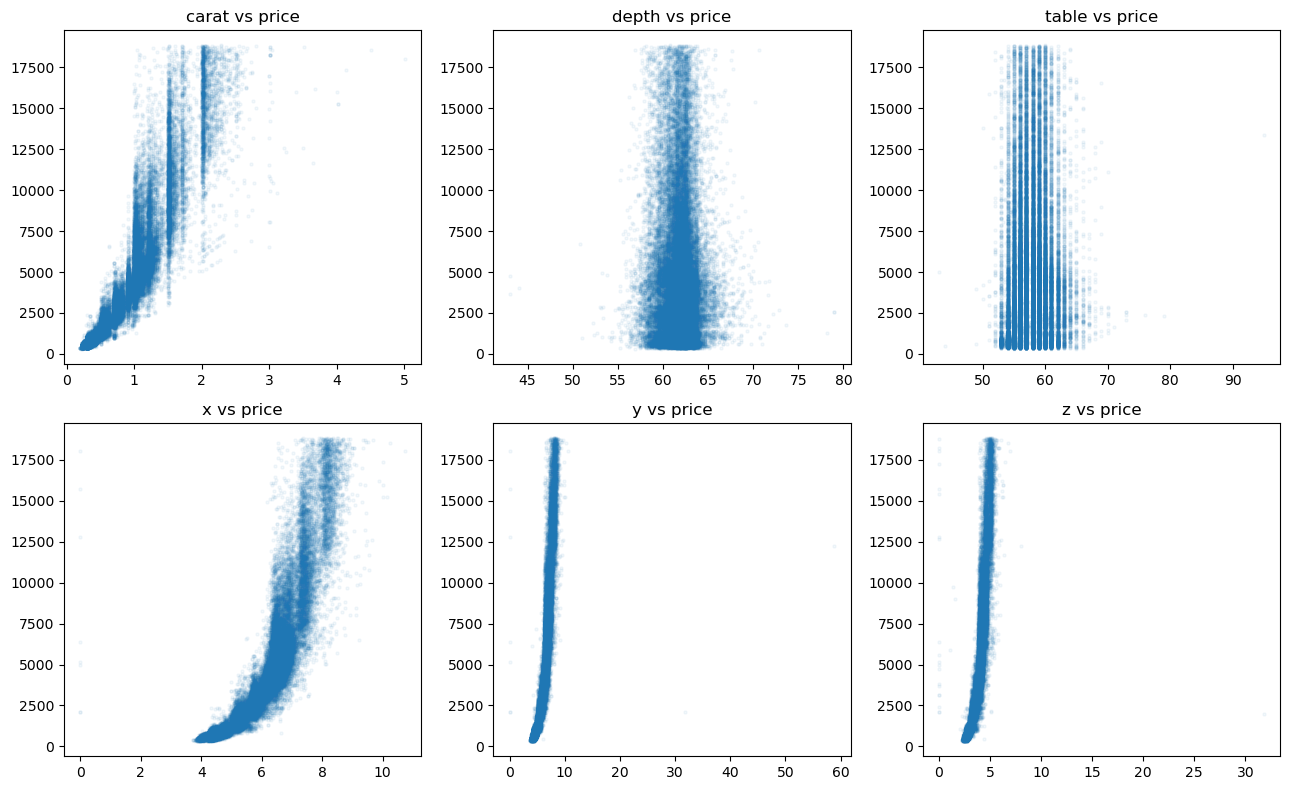

In [4]:
num_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.scatter(df[col], df['price'], alpha=0.05, s=5)
    ax.set_title(f"{col} vs price")
plt.tight_layout()
plt.show()

`carat`이 `price`와 가장 뚜렷한 관계를 보입니다. 캐럿이 커질수록 가격이 올라가는데, 일직선이라기보단 위로 휘어지는 형태입니다 (역시 로그 변환이 도움될 수 있는 부분입니다).

`x`, `y`, `z`(크기)도 `carat`과 비슷한 패턴을 보이는데, 사실 캐럿 자체가 부피(크기)와 밀접한 관련이 있어서 그렇습니다. `depth`, `table`은 상대적으로 `price`와의 관계가 뚜렷하지 않네요.

이번엔 범주형 변수(`cut`, `color`, `clarity`)별로 가격 분포가 어떻게 다른지 박스플롯으로 확인해보겠습니다.

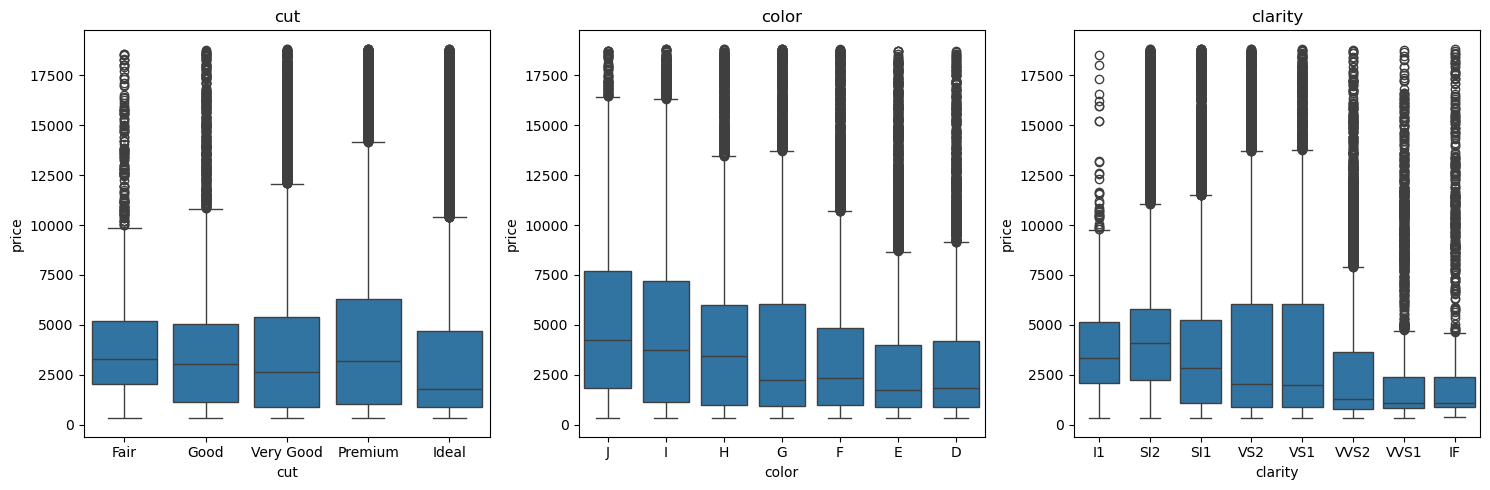

In [6]:
cat_cols = ['cut', 'color', 'clarity']
cat_orders = {
    'cut': ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],
    'color': ['J', 'I', 'H', 'G', 'F', 'E', 'D'],
    'clarity': ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, cat_cols):
    sns.boxplot(data=df, x=col, y='price', order=cat_orders[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

등급이 좋을수록(오른쪽으로 갈수록) 가격이 비쌀 것 같지만, 실제론 그렇게 뚜렷하지 않죠? 오히려 `cut`이 Ideal인데도 가격 중앙값이 낮아 보입니다.

## 4. 범주형 인코딩

`cut`, `color`, `clarity`는 순서가 있는 범주형(순서형) 변수이므로, 순서 정보를 살리는 순서형 인코딩을 적용하겠습니다.

In [8]:
X = df.drop(columns=['price'])
y = df['price']

for col in cat_cols:
    order = cat_orders[col]
    mapping = {v: i for i, v in enumerate(order)}
    X[col] = X[col].map(mapping)

X.head()

,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,4,5,1,61.5,55.0,3.95,3.98,2.43
1,0.21,3,5,2,59.8,61.0,3.89,3.84,2.31
2,0.23,1,5,4,56.9,65.0,4.05,4.07,2.31
3,0.29,3,1,3,62.4,58.0,4.20,4.23,2.63
4,0.31,1,0,1,63.3,58.0,4.34,4.35,2.75


등급이 낮을수록 0, 높을수록 큰 숫자로 바뀐 걸 확인할 수 있습니다.

## 5. 평가지표 정하기 & train/test 분리

자, 여기서 평가 지표는 어떻게 결정하는게 좋을까요?

가격을 예측하는 문제이므로 예측값과 실제값의 차이(오차)를 그대로 보여주는 **MAE(평균 절대 오차)**를 기본 지표로 사용하겠습니다. 실제 달러 단위로 해석하기도 쉽습니다.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(43152, 9) (10788, 9)


## 6. 베이스라인 모델 학습

먼저 선형회귀로 베이스라인을 만들어보겠습니다.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
print(f"MAE: {mae:.1f}")
print(f"RMSE: {rmse:.1f}")

MAE: 805.3
RMSE: 1224.6


평균적으로 실제 가격과 500달러 안팎의 차이가 나네요. `price`의 평균이 약 3,900달러였던 걸 감안하면 꽤 큰 오차입니다.

RMSE가 MAE보다 훨씬 크다는 것도 눈여겨볼 부분입니다. 이는 오차가 클수록 제곱으로 커지는 RMSE 특성상, **일부 데이터에서 유독 큰 오차**가 나고 있다는 신호입니다. 어디서 이런 오차가 나는지 살펴보겠습니다.

## 7. 오차 분석

예측이 크게 틀린 구간이 있는지, `carat`(캐럿) 기준으로 나눠서 살펴보겠습니다.

In [11]:
result = X_test.copy()
result['price'] = y_test
result['pred'] = pred
result['error'] = result['pred'] - result['price']
result['abs_error'] = result['error'].abs()

result.sort_values('abs_error', ascending=False).head(10)

,carat,cut,color,clarity,depth,table,x,y,z,price,pred,error,abs_error
25998,4.01,3,1,0,61.0,61.0,10.14,10.10,6.17,15223,32427.345127,17204.345127,17204.345127
25999,4.01,3,0,0,62.5,62.0,10.02,9.94,6.24,15223,32054.799738,16831.799738,16831.799738
26444,4.00,2,1,0,63.3,58.0,10.01,9.94,6.31,15984,32198.109495,16214.109495,16214.109495
24328,3.50,4,2,0,62.8,57.0,9.65,9.59,6.03,12587,27759.085407,15172.085407,15172.085407
21862,3.01,3,4,0,62.2,56.0,9.24,9.13,5.73,9925,23429.698412,13504.698412,13504.698412
27679,3.51,3,0,3,62.5,59.0,9.66,9.63,6.03,18701,28565.175848,9864.175848,9864.175848
20297,2.50,0,3,0,65.1,59.0,8.55,8.39,5.53,8711,17509.842848,8798.842848,8798.842848
27673,1.50,2,3,3,60.7,59.0,7.31,7.38,4.46,18691,9920.447876,-8770.552124,8770.552124
17897,2.30,3,3,0,60.2,59.0,8.71,8.56,5.19,7226,15992.644824,8766.644824,8766.644824
24784,2.75,4,6,0,60.9,57.0,9.04,8.98,5.49,13156,21652.344185,8496.344185,8496.344185


가장 오차가 큰 케이스들을 보면 캐럿이 큰(고가) 다이아몬드에 몰려있는 걸 볼 수 있습니다. 캐럿 구간별로 평균 오차를 집계해서 더 명확히 확인해보겠습니다.

In [13]:
result['carat_bin'] = pd.cut(result['carat'], bins=[0, 0.5, 1, 1.5, 2, 5])
result.groupby('carat_bin')[['abs_error']].mean()

/var/folders/px/v7_qzrl907d919ql0sn3f74r0000gn/T/ipykernel_30793/354613049.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result.groupby('carat_bin')[['abs_error']].mean()


,abs_error
carat_bin,
"(0.0, 0.5]",654.253769
"(0.5, 1.0]",489.626501
"(1.0, 1.5]",966.709493
"(1.5, 2.0]",1880.538001
"(2.0, 5.0]",2157.565472


역시 캐럿이 커질수록(비싼 다이아몬드일수록) 평균 절대 오차도 같이 커집니다. 저가 구간에서는 몇십 달러 수준이지만 고가 구간에서는 몇백~천 달러 단위로 틀리고 있습니다.

여기서 한 번 price의 분포를 출력해 보도록 하겠습니다.

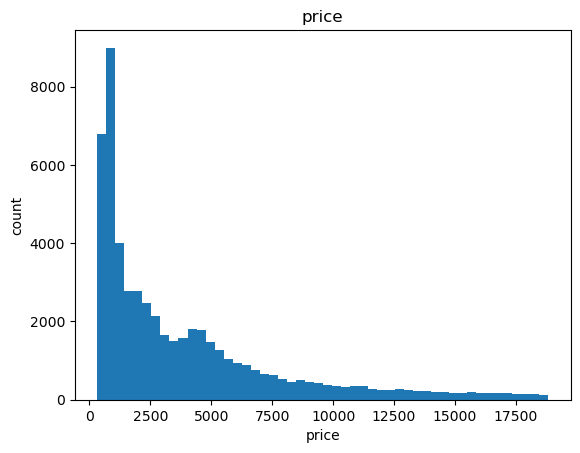

In [14]:
plt.hist(df['price'], bins=50)
plt.title("price")
plt.xlabel("price")
plt.ylabel("count")
plt.show()

이건 앞서 봤던 `price`의 치우친 분포와 관련이 있습니다. 선형회귀는 절대 오차(차이)를 기준으로 맞추다 보니, 가격이 큰 쪽에서 상대적으로 더 크게 틀려도 학습 과정에서 잘 드러나지 않을 수 있습니다.

## 8. 개선 시도 — 타겟 로그 변환

`price`를 그대로 예측하는 대신, `log(price)`를 예측하도록 바꿔서 같은 방식으로 다시 학습해보겠습니다.

In [16]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model_log = LinearRegression()
model_log.fit(X_train, y_train_log)

pred_log = model_log.predict(X_test)
pred_from_log = np.expm1(pred_log)   # 다시 원래 가격 단위로 복원

mae_log = mean_absolute_error(y_test, pred_from_log)
rmse_log = mean_squared_error(y_test, pred_from_log) ** 0.5

print(f"MAE  (기존): {mae:.1f} -> (log 변환): {mae_log:.1f}  ({(mae_log - mae) / mae * 100:+.1f}%)")
print(f"RMSE (기존): {rmse:.1f} -> (log 변환): {rmse_log:.1f}  ({(rmse_log - rmse) / rmse * 100:+.1f}%)")

MAE  (기존): 805.3 -> (log 변환): 536.2  (-33.4%)
RMSE (기존): 1224.6 -> (log 변환): 1221.4  (-0.3%)


처음 베이스라인과 비교해보면 MAE와 RMSE 모두 개선된 걸 볼 수 있습니다.

`log` 변환을 하면 모델이 절대적인 달러 차이 대신 **상대적인(비율) 차이**를 기준으로 학습하게 되어서, 고가 구간에서의 큰 오차에 덜 휘둘리게 됩니다. 캐럿 구간별로 다시 확인해보겠습니다.

In [17]:
result['pred_log'] = pred_from_log
result['abs_error_log'] = (result['pred_log'] - result['price']).abs()

result.groupby('carat_bin')[['abs_error', 'abs_error_log']].mean()

/var/folders/px/v7_qzrl907d919ql0sn3f74r0000gn/T/ipykernel_30793/1877037755.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result.groupby('carat_bin')[['abs_error', 'abs_error_log']].mean()


,abs_error,abs_error_log
carat_bin,,
"(0.0, 0.5]",654.253769,101.374307
"(0.5, 1.0]",489.626501,313.291875
"(1.0, 1.5]",966.709493,826.115268
"(1.5, 2.0]",1880.538001,1558.392474
"(2.0, 5.0]",2157.565472,3206.211821


고가 구간에서의 오차가 확실히 줄어든 걸 볼 수 있습니다. 대신 저가 구간에서는 큰 차이가 없거나 오히려 미세하게 늘 수도 있는데, 이는 트레이드오프로 이해하면 됩니다.

## 9. 서로 겹치는 정보 정리하기 (carat, x, y, z)

`carat`(무게)과 `x`, `y`, `z`(가로/세로/깊이 길이)는 사실 같은 이야기를 하고 있는 변수들입니다. 다이아몬드가 크면 무겁고(carat이 크고), 가로·세로·깊이도 다 같이 커지기 때문이죠.

이렇게 여러 변수가 서로 거의 같은 정보를 중복해서 담고 있으면, 모델 입장에서는 "가격 상승의 공을 이 4개 변수 중 누구에게 얼마나 나눠줘야 하는지" 헷갈려 합니다. 그 결과 각 변수의 계수(영향력)가 불안정하게 나오거나, 심지어 상식과 반대되는 부호(예: 커질수록 가격이 낮아진다는 식)로 나오기도 합니다. 예측 성능 자체는 크게 나쁘지 않을 수 있지만, "어떤 변수가 가격에 얼마나 영향을 주는지" 해석하려고 하면 신뢰하기 어려워지는 거죠.

먼저 이 네 변수가 서로 얼마나 겹치는 정보를 담고 있는지 상관관계로 확인해보겠습니다.

In [18]:
corr = X_train[['carat', 'x', 'y', 'z']].corr()
corr

,carat,x,y,z
carat,1.000000,0.974844,0.945997,0.948339
x,0.974844,1.000000,0.968869,0.965858
y,0.945997,0.968869,1.000000,0.942767
z,0.948339,0.965858,0.942767,1.000000


거의 모든 값이 0.95 이상으로, 사실상 같은 정보를 4번 반복해서 넣고 있는 셈입니다. 이번엔 실제로 각 변수의 계수(coefficient)를 뽑아서, 이 중복이 모델에 어떤 영향을 주는지 직접 확인해보겠습니다.

In [19]:
coef_before = pd.Series(model_log.coef_, index=X_train.columns)
coef_before[['carat', 'x', 'y', 'z']]

carat   -0.646464
x        1.174092
y        0.034990
z        0.038103
dtype: float64

위 데이터 결과들은 가격을 예측하는 모델에서, "다른 변수들을 고정한 채 이 변수 하나만 늘렸을 때 가격이 얼마나 변하는가"를 나타내는 계수입니다.

그런데 지금 결과를 보시면 캐럿이 증가하면 오히려 가격이 감소하는 현상이 발생하고 있습니다..!

이상하죠? 아까 그래프로 그려 봤을 때도 데이터 분포 상 캐럿이 증가할수록 가격이 당연히 상승했었는데, 그 패턴을 제대로 학습하지 못한겁니다.

여기서 앞의 상관관계 행렬을 떠올려 보면 저희가 하나의 가정을 세울 수 있습니다.

**가정 : "같은 정보가 중복해서 들어가고 있는 것이 모델에 악영향을 주고 있다."**

이제 `x`, `y`, `z`를 빼고 `carat` 하나로만 크기 정보를 표현해서 다시 학습해보겠습니다. 성능이 얼마나 달라지는지, 그리고 `carat`의 계수가 어떻게 바뀌는지 함께 확인해봅니다.

In [21]:
X_train_reduced = X_train.drop(columns=['x', 'y', 'z'])
X_test_reduced = X_test.drop(columns=['x', 'y', 'z'])

model_reduced = LinearRegression()
model_reduced.fit(X_train_reduced, y_train_log)

pred_reduced = np.expm1(model_reduced.predict(X_test_reduced))

mae_reduced = mean_absolute_error(y_test, pred_reduced)
rmse_reduced = mean_squared_error(y_test, pred_reduced) ** 0.5

print(f"MAE  (log 변환): {mae_log:.1f} -> (x,y,z 제거): {mae_reduced:.1f}  ({(mae_reduced - mae_log) / mae_log * 100:+.1f}%)")
print(f"RMSE (log 변환): {rmse_log:.1f} -> (x,y,z 제거): {rmse_reduced:.1f}  ({(rmse_reduced - rmse_log) / rmse_log * 100:+.1f}%)")

coef_after = pd.Series(model_reduced.coef_, index=X_train_reduced.columns)
print()
print("carat 계수 비교")
print(f"  x,y,z 포함: {coef_before['carat']:.4f}")
print(f"  x,y,z 제거: {coef_after['carat']:.4f}")

MAE  (log 변환): 536.2 -> (x,y,z 제거): 2139.8  (+299.1%)
RMSE (log 변환): 1221.4 -> (x,y,z 제거): 27762.1  (+2173.0%)

carat 계수 비교
  x,y,z 포함: -0.6465
  x,y,z 제거: 2.1751


직접 실행해보면 예상과 다른 결과가 나옵니다. `carat`의 계수는 2.17로 커지면서 부호가 양수로 바뀌어 상식과 맞아떨어지지만(크기 정보를 이제 혼자 온전히 담당하니까요), 예측 성능은 오히려 크게 나빠집니다(MAE +299%, RMSE +2173%).

즉, 겹치는 변수를 정리하는 것이 항상 이득은 아닙니다. 이번 경우엔 `x`, `y`, `z`가 단순히 중복 정보만 담고 있었던 게 아니라, `carat` 하나로는 표현하기 어려운 비선형적인 관계를 여러 변수의 조합으로 우회해서 표현해주는 역할도 하고 있었던 겁니다. 계수를 상식에 맞게 정리하는 것과, 예측 성능을 유지하는 것은 서로 다른 목표이며 항상 같이 따라오지 않는다는 걸 보여주는 사례입니다.

## 10. 여러 모델 비교하기

지금까지는 선형회귀 하나로만 이것저것 시도해봤는데, 회귀 문제에서 자주 쓰이는 다른 모델들도 같이 돌려서 비교해보겠습니다.

- **Ridge, Lasso**: 선형회귀에 "규제(제약)"를 추가한 모델입니다. 계수가 너무 커지지 않도록 억눌러서, 변수끼리 겹치는 정보가 있어도 좀 더 안정적인 계수를 얻을 수 있습니다. `alpha`가 규제 강도를 정하는 하이퍼파라미터입니다(클수록 강하게 억누름).
- **RandomForest, GradientBoosting**: 여러 개의 결정트리를 결합한 앙상블 모델입니다. 선형회귀와 달리 굽은 관계나 변수 간 상호작용을 자동으로 학습할 수 있어서, 로그 변환이나 겹치는 변수 정리 같은 작업 없이도 좋은 성능이 나올 수 있습니다. `n_estimators`(트리 개수), `max_depth`(트리 깊이), `learning_rate`(학습 속도) 등이 대표적인 하이퍼파라미터입니다.

모두 `carat`, `x`, `y`, `z`를 포함한 전체 변수와, 지금까지 성능이 가장 좋았던 로그 변환 타겟(`y_train_log`)으로 학습합니다.

In [22]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    'LinearRegression': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Lasso (alpha=0.01)': Lasso(alpha=0.01),
    'RandomForest (n_estimators=200, max_depth=12)': RandomForestRegressor(
        n_estimators=200, max_depth=12, random_state=42, n_jobs=-1
    ),
    'GradientBoosting (n_estimators=200, lr=0.1, max_depth=3)': GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42
    ),
}

rows = []
for name, m in models.items():
    m.fit(X_train, y_train_log)
    pred = np.expm1(m.predict(X_test))
    rows.append({
        'model': name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': mean_squared_error(y_test, pred) ** 0.5,
    })

model_comparison = pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)
model_comparison

,model,MAE,RMSE
0,"RandomForest (n_estimators=200, max_depth=12)",276.069922,547.569982
1,"GradientBoosting (n_estimators=200, lr=0.1, ma...",285.083684,554.929197
2,LinearRegression,536.178812,1221.370741
3,Ridge (alpha=1.0),536.599681,1223.680512
4,Lasso (alpha=0.01),713.775339,2213.685983


결과를 보면:

| 모델 | MAE | RMSE |
|---|---|---|
| RandomForest | 276.1 | 547.6 |
| GradientBoosting | 285.1 | 554.9 |
| LinearRegression | 536.2 | 1221.4 |
| Ridge | 536.6 | 1223.7 |
| Lasso | 713.8 | 2213.7 |

- **RandomForest, GradientBoosting**이 선형 계열보다 MAE 기준으로 절반 수준까지 오차를 줄였습니다. 트리 기반 모델은 `carat`-가격 사이의 굽은 관계나 변수 간 상호작용을 알아서 학습하기 때문에, 앞서 우리가 로그 변환이나 변수 정리로 애써 보완해야 했던 문제들을 별다른 전처리 없이 해결한 셈입니다.
- **Ridge**는 `alpha=1.0` 정도의 규제로는 LinearRegression과 거의 차이가 없습니다. 규제 강도가 지금 데이터 스케일에 비해 약해서 계수를 크게 억누르지 못한 것으로 보입니다.
- **Lasso**는 오히려 성능이 나빠졌습니다. `alpha=0.01`이 작아 보여도 Lasso는 계수를 아예 0으로 만들어버릴 수 있는데, 이 과정에서 `carat`처럼 중요한 변수의 영향력이 필요 이상으로 깎였을 가능성이 있습니다. 규제 모델은 `alpha`를 어떻게 잡느냐에 따라 결과가 크게 달라진다는 걸 보여주는 예입니다.

여기서 쓴 `n_estimators`, `max_depth`, `alpha` 같은 하이퍼파라미터는 모두 임의로 골라본 값입니다. 실제로 더 좋은 값을 찾으려면 `GridSearchCV`나 `RandomizedSearchCV` 같은 도구로 여러 조합을 체계적으로 탐색해야 합니다.

## 11. 정리

- `carat`(캐럿)이 `price`를 설명하는 가장 강력한 변수였고, `cut`/`color`/`clarity` 같은 등급 변수의 효과는 캐럿에 가려져 단순 비교로는 잘 드러나지 않았습니다.
- `price`가 한쪽으로 치우친 분포를 가지고 있어서, 그대로 예측하면 고가 구간에서 오차가 크게 몰리는 문제가 있었습니다.
- 타겟을 로그 변환해서 학습하니 특히 고가 구간의 오차가 줄어들며 전체 지표도 개선됐습니다.
- `carat`과 `x`/`y`/`z`는 서로 겹치는 정보를 담고 있어서 계수 해석을 불안정하게 만들었지만, 이 변수들을 지우는 것이 항상 이득은 아니었습니다. `x`, `y`, `z`가 `carat`-가격 사이의 곡선 관계를 간접적으로 보완해주고 있었기 때문에, 이들을 빼자 오히려 예측 성능이 크게 나빠졌습니다.
- 여러 모델을 비교해보니 RandomForest, GradientBoosting 같은 트리 기반 앙상블 모델이 선형회귀 계열보다 훨씬 좋은 성능을 보였습니다.